In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Output directory — all Ankh results go here
OUT_DIR = "ankh_results"
os.makedirs(OUT_DIR, exist_ok=True)
print("Output directory:", os.path.abspath(OUT_DIR))

Output directory: /home/saishyam/Protein_dynamics/Dynamic_properties/Protein_Cell_tissue_confidence/ankh_results


In [11]:
# ============================================================
# LOAD DATA & ASSIGN REAL TISSUE COLUMN NAMES
# ============================================================

# --- Tissue names from original matrix (row 0, cols 3+) ---
raw_meta = pd.read_csv(
    "gene_attribute_matrix.txt",
    sep="\t", header=None, nrows=1, low_memory=False
)
tissue_names_raw = raw_meta.iloc[0, 3:].tolist()          # 243 names

# --- Load mapped CSV ---
df = pd.read_csv("TISSUES_with_UniProt_mapped.csv", low_memory=False)
print("Loaded shape:", df.shape)

# Tissue columns sit between GeneID (col 2) and UniProt_ID (last col)
tissue_cols_orig = df.columns[3:-1].tolist()               # 246 cols

# Build tissue name map — pad/trim to match
n_tissue_cols = len(tissue_cols_orig)
n_tissue_names = len(tissue_names_raw)

# Deduplicate tissue names (same approach used for pandas col renaming)
seen = {}
deduped_names = []
for name in tissue_names_raw:
    if name not in seen:
        seen[name] = 0
        deduped_names.append(str(name))
    else:
        seen[name] += 1
        deduped_names.append(f"{name}_{seen[name]}")

# If CSV has more tissue cols than names, pad with generated names
if n_tissue_cols > n_tissue_names:
    extra = [f"tissue_extra_{i}" for i in range(n_tissue_cols - n_tissue_names)]
    deduped_names = deduped_names + extra
else:
    deduped_names = deduped_names[:n_tissue_cols]

# Rename tissue columns in df
rename_map = dict(zip(tissue_cols_orig, deduped_names))
df = df.rename(columns=rename_map)
TISSUE_COLS = deduped_names

print(f"Tissue columns: {len(TISSUE_COLS)}")
print("First 5 tissues:", TISSUE_COLS[:5])
print("Last 5 tissues:", TISSUE_COLS[-5:])
df[["GeneSym", "ENSP", "UniProt_ID"] + TISSUE_COLS[:3]].head()

Loaded shape: (13705, 250)
Tissue columns: 246
First 5 tissues: ['fetus', 'placenta', 'embryonic structure', 'organism form', 'internal female genital organ']
Last 5 tissues: ['larynx', 'ear', 'tissue_extra_0', 'tissue_extra_1', 'tissue_extra_2']


,GeneSym,ENSP,UniProt_ID,fetus,placenta,embryonic structure
0,ZNF627,ENSP00000354414,Q7L945,0.0,0.0,0.0
1,ZNF544,ENSP00000269829,Q6NX49,0.0,0.0,0.0
2,ZNF540,ENSP00000324598,Q8NDQ6,0.0,0.0,0.0
3,ZNF512,ENSP00000347648,Q96ME7,0.0,0.0,0.0
4,ADAT1,ENSP00000310015,Q9BUB4,0.0,0.0,0.0


Tissues with >= 10 positives and not all-1: 235 / 246
Positive fraction — mean: 0.0722, min: 0.0010, max: 0.9987


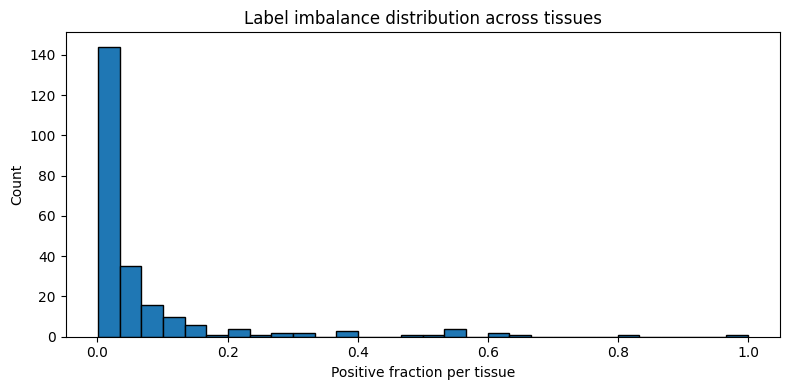

In [12]:
# ============================================================
# LABEL MATRIX — filter out tissues with no positive examples
# ============================================================

label_df = df[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32)

pos_counts = (label_df == 1).sum()
valid_tissues = pos_counts[(pos_counts >= 10) & (pos_counts < len(df))].index.tolist()

print(f"Tissues with >= 10 positives and not all-1: {len(valid_tissues)} / {len(TISSUE_COLS)}")

# Restrict to valid tissues only
label_df = label_df[valid_tissues]
TISSUE_COLS = valid_tissues

pos_frac = (label_df == 1).mean()
print(f"Positive fraction — mean: {pos_frac.mean():.4f}, min: {pos_frac.min():.4f}, max: {pos_frac.max():.4f}")

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pos_frac, bins=30, edgecolor="black")
ax.set_xlabel("Positive fraction per tissue")
ax.set_ylabel("Count")
ax.set_title("Label imbalance distribution across tissues")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "label_distribution.png"), dpi=150)
plt.show()

In [13]:

# ============================================================
# LOAD PRE-COMPUTED ANKH EMBEDDINGS
# (same cache used in acetylation pipeline)
# ============================================================

from pathlib import Path
import numpy as np

EMBED_FILE = (
    Path.cwd() / ".." / ".." / "all_uniref"
    / "ankh_embedding_cache" / "pooled_embeddings.npz"
).resolve()

print(f"Embedding file: {EMBED_FILE}")
print(f"Exists: {EMBED_FILE.exists()}")

cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()    # dict: UniProt_ID → (768,)
attn_pool = cache["attn"].item()   # dict: UniProt_ID → (768,)

emb_dim = next(iter(max_pool.values())).shape[0]
print(f"Proteins in cache (max) : {len(max_pool)}")
print(f"Proteins in cache (attn): {len(attn_pool)}")
print(f"Embedding dim           : {emb_dim}")

# How many of our proteins are covered?
our_ids   = df["UniProt_ID"].dropna().unique().tolist()
covered   = [uid for uid in our_ids if uid in max_pool]
print(f"\nOur proteins          : {len(our_ids)}")
print(f"Covered by cache (max): {len(covered)}")


Embedding file: /home/saishyam/Protein_dynamics/all_uniref/ankh_embedding_cache/pooled_embeddings.npz
Exists: True
Proteins in cache (max) : 18459
Proteins in cache (attn): 18459
Embedding dim           : 768

Our proteins          : 13692
Covered by cache (max): 13081


In [14]:

# ============================================================
# BUILD X (embeddings) AND Y (labels) FOR BOTH POOL TYPES
# ============================================================

from sklearn.model_selection import train_test_split

def collect_embeddings(df_in, pool_dict, label=""):
    """Stack embeddings for each protein; report missing."""
    vecs, missing = [], []
    for uid in df_in["UniProt_ID"]:
        vec = pool_dict.get(uid)
        if vec is None:
            missing.append(uid)
        else:
            vecs.append(vec)
    if missing:
        print(f"[{label}] Missing embeddings: {len(missing)}")
    return np.stack(vecs).astype(np.float32)

# Keep only proteins that have embeddings in the max pool
df_ml = df[df["UniProt_ID"].isin(max_pool)].reset_index(drop=True)
print(f"Proteins with embeddings: {len(df_ml)}")

X_max  = collect_embeddings(df_ml, max_pool,  "max")
X_attn = collect_embeddings(df_ml, attn_pool, "attn")
Y      = df_ml[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

print(f"X_max  shape : {X_max.shape}")
print(f"X_attn shape : {X_attn.shape}")
print(f"Y      shape : {Y.shape}")

# Shared 80/20 split index
idx = np.arange(len(df_ml))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

splits = {
    "max":  (X_max[idx_train],  X_max[idx_test]),
    "attn": (X_attn[idx_train], X_attn[idx_test]),
}
Y_train, Y_test = Y[idx_train], Y[idx_test]

print(f"\nTrain: {len(idx_train)}  |  Test: {len(idx_test)}")
print(f"Tissues (labels): {Y.shape[1]}")


Proteins with embeddings: 13093
X_max  shape : (13093, 768)
X_attn shape : (13093, 768)
Y      shape : (13093, 235)

Train: 10474  |  Test: 2619
Tissues (labels): 235


In [15]:

# ============================================================
# DEDUPLICATION — remove duplicate proteins by UniProt ID
# ============================================================

n_before = len(df_ml)
dup_mask = df_ml["UniProt_ID"].duplicated(keep="first")
n_dups   = dup_mask.sum()

print(f"Proteins before dedup : {n_before}")
print(f"Duplicate UniProt IDs : {n_dups}")

if n_dups > 0:
    print(f"\nExample duplicates:")
    dup_ids = df_ml.loc[dup_mask, "UniProt_ID"].value_counts().head(5)
    print(dup_ids.to_string())

    df_ml = df_ml[~dup_mask].reset_index(drop=True)

    # Rebuild embeddings + labels from deduped df_ml
    X_max  = collect_embeddings(df_ml, max_pool,  "max")
    X_attn = collect_embeddings(df_ml, attn_pool, "attn")
    Y      = df_ml[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

    # Re-do 80/20 split for the 235-tissue task
    idx = np.arange(len(df_ml))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
    splits = {
        "max":  (X_max[idx_train],  X_max[idx_test]),
        "attn": (X_attn[idx_train], X_attn[idx_test]),
    }
    Y_train, Y_test = Y[idx_train], Y[idx_test]

    print(f"\nProteins after  dedup : {len(df_ml)}")
    print(f"Train: {len(idx_train)}  |  Test: {len(idx_test)}")
else:
    print("No duplicates found — data is clean.")


Proteins before dedup : 13093
Duplicate UniProt IDs : 12

Example duplicates:
UniProt_ID
Q96JG8    1
P0DN86    1
P69905    1
P84243    1
Q02325    1

Proteins after  dedup : 13081
Train: 10464  |  Test: 2617


In [16]:
# ============================================================
# BUILD X (embeddings) AND Y (labels) MATRICES
# ============================================================

from sklearn.model_selection import train_test_split

# Only keep proteins that have embeddings
has_emb = df_with_seq["UniProt_ID"].isin(emb_dict)
df_ml = df_with_seq[has_emb].reset_index(drop=True)
print(f"Proteins with embeddings: {len(df_ml)}")

X = np.stack([emb_dict[uid] for uid in df_ml["UniProt_ID"]]).astype(np.float32)
Y = df_ml[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

# Train / test split (stratify on at least one multi-hot row is hard; use random)
idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X_train, X_test = X[idx_train], X[idx_test]
Y_train, Y_test = Y[idx_train], Y[idx_test]

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Number of output tissues (labels): {Y.shape[1]}")

NameError: name 'df_with_seq' is not defined

In [17]:

# ============================================================
# MLP MODEL — shared backbone + multi-label output head
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class TissueEnrichmentMLP(nn.Module):
    """Shared backbone → per-tissue binary classification."""
    def __init__(self, input_dim: int, num_tissues: int):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head = nn.Linear(256, num_tissues)

    def forward(self, x):
        return self.head(self.backbone(x))   # logits (B, num_tissues)


# Per-tissue positive weights (same for both pools — labels don't change)
pos_counts_tr = Y_train.sum(axis=0)
neg_counts_tr = len(Y_train) - pos_counts_tr
pos_weights   = np.where(pos_counts_tr > 0, neg_counts_tr / pos_counts_tr, 1.0)
pos_weights   = np.clip(pos_weights, 1.0, 50.0).astype(np.float32)
pos_weight_tensor = torch.from_numpy(pos_weights).to(device)

print(f"pos_weight — min: {pos_weights.min():.2f}, max: {pos_weights.max():.2f}, mean: {pos_weights.mean():.2f}")
print(f"Input dim   : {emb_dim}")
print(f"Output dim  : {Y_train.shape[1]} tissues")


Device: cuda
pos_weight — min: 1.00, max: 50.00, mean: 34.65
Input dim   : 768
Output dim  : 235 tissues



  Training with MAX pooling
  Epoch 010/40 | Loss: 0.4566
  Epoch 020/40 | Loss: 0.3185
  Epoch 030/40 | Loss: 0.2478
  Epoch 040/40 | Loss: 0.2287

  Training with ATTN pooling
  Epoch 010/40 | Loss: 0.5074
  Epoch 020/40 | Loss: 0.3943
  Epoch 030/40 | Loss: 0.3274
  Epoch 040/40 | Loss: 0.3051


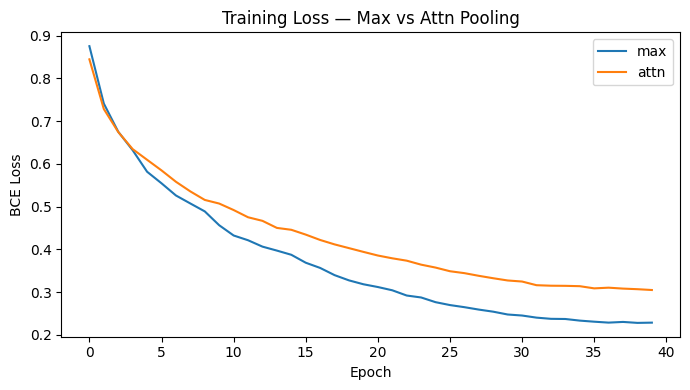

In [18]:

# ============================================================
# TRAINING — one MLP per pooling strategy
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score

EPOCHS     = 40
BATCH_SIZE = 64
LR         = 1e-3

trained_models = {}
train_loss_curves = {}

for pool_name, (X_tr, X_te) in splits.items():

    print(f"\n{'='*50}")
    print(f"  Training with {pool_name.upper()} pooling")
    print(f"{'='*50}")

    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(Y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_te),  torch.from_numpy(Y_test))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model     = TissueEnrichmentMLP(input_dim=X_tr.shape[1], num_tissues=Y_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    losses = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:03d}/{EPOCHS} | Loss: {avg_loss:.4f}")

    trained_models[pool_name]     = (model, test_loader)
    train_loss_curves[pool_name]  = losses

# Training curves
fig, ax = plt.subplots(figsize=(7, 4))
for pool_name, losses in train_loss_curves.items():
    ax.plot(losses, label=pool_name)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Training Loss — Max vs Attn Pooling")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_loss.png"), dpi=150)
plt.show()



[MAX pool]  tissues evaluated: 235
  Macro ROC-AUC : 0.7558 ± 0.0793
  Macro PR-AUC  : 0.2202  ± 0.1690

[ATTN pool]  tissues evaluated: 235
  Macro ROC-AUC : 0.7920 ± 0.0682
  Macro PR-AUC  : 0.2650  ± 0.1837


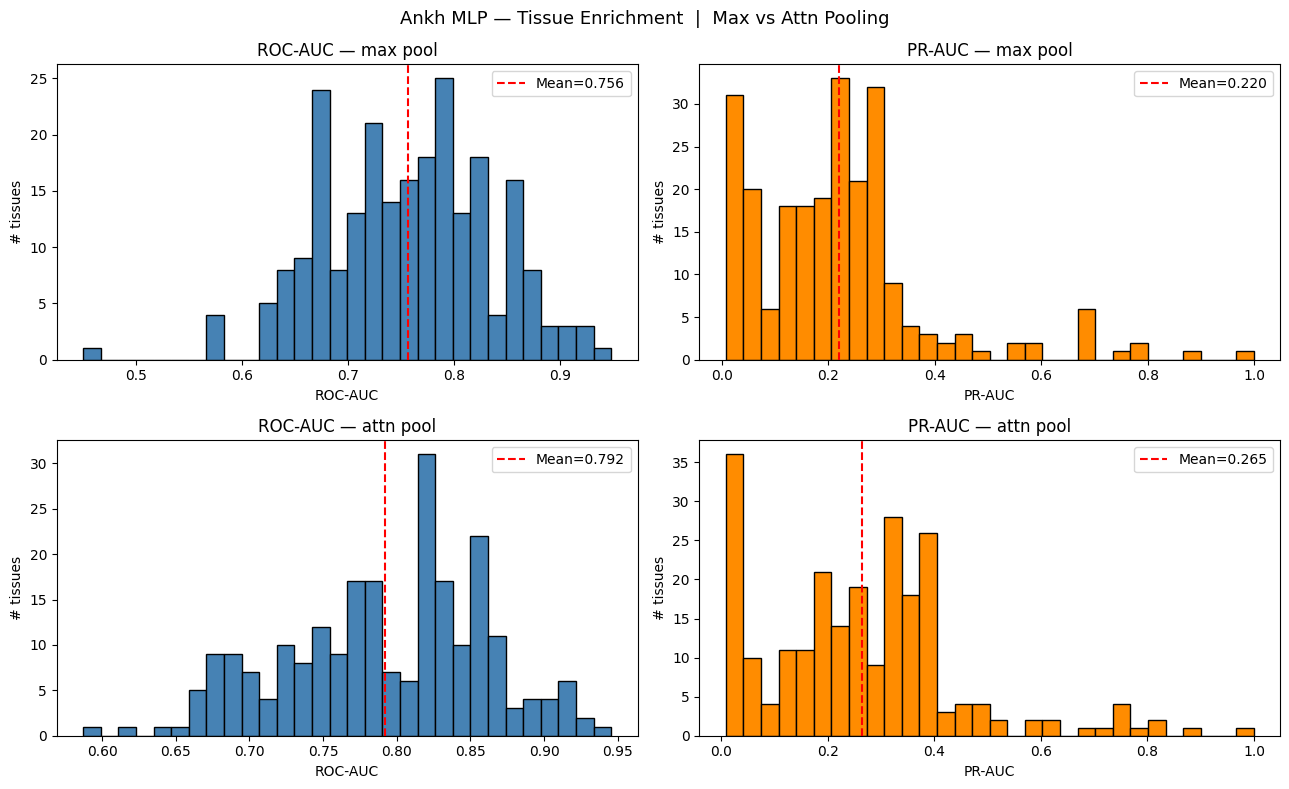

In [19]:

# ============================================================
# EVALUATION — per-tissue ROC-AUC and PR-AUC (both pools)
# ============================================================

eval_results = {}   # pool_name → {roc_aucs, pr_aucs, tissue_names_eval}

for pool_name, (model, test_loader) in trained_models.items():

    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device)).cpu().numpy()
            all_logits.append(logits)
            all_labels.append(yb.numpy())

    Y_pred_logits = np.concatenate(all_logits, axis=0)
    Y_true        = np.concatenate(all_labels, axis=0)
    Y_prob        = 1 / (1 + np.exp(-Y_pred_logits))

    roc_aucs, pr_aucs, tnames = [], [], []
    for i, tname in enumerate(TISSUE_COLS):
        y_true_i = Y_true[:, i]
        y_prob_i = Y_prob[:, i]
        if y_true_i.sum() == 0 or y_true_i.sum() == len(y_true_i):
            continue
        roc_aucs.append(roc_auc_score(y_true_i, y_prob_i))
        pr_aucs.append(average_precision_score(y_true_i, y_prob_i))
        tnames.append(tname)

    roc_aucs = np.array(roc_aucs)
    pr_aucs  = np.array(pr_aucs)
    eval_results[pool_name] = dict(
        roc_aucs=roc_aucs, pr_aucs=pr_aucs,
        tissue_names=tnames, Y_true=Y_true, Y_prob=Y_prob
    )

    print(f"\n[{pool_name.upper()} pool]  tissues evaluated: {len(roc_aucs)}")
    print(f"  Macro ROC-AUC : {roc_aucs.mean():.4f} ± {roc_aucs.std():.4f}")
    print(f"  Macro PR-AUC  : {pr_aucs.mean():.4f}  ± {pr_aucs.std():.4f}")

# Distribution plot — both pools side by side
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (pool_name, res) in enumerate(eval_results.items()):
    axes[row, 0].hist(res["roc_aucs"], bins=30, edgecolor="black", color="steelblue")
    axes[row, 0].axvline(res["roc_aucs"].mean(), color="red", linestyle="--",
                         label=f"Mean={res['roc_aucs'].mean():.3f}")
    axes[row, 0].set_title(f"ROC-AUC — {pool_name} pool")
    axes[row, 0].set_xlabel("ROC-AUC")
    axes[row, 0].set_ylabel("# tissues")
    axes[row, 0].legend()

    axes[row, 1].hist(res["pr_aucs"], bins=30, edgecolor="black", color="darkorange")
    axes[row, 1].axvline(res["pr_aucs"].mean(), color="red", linestyle="--",
                         label=f"Mean={res['pr_aucs'].mean():.3f}")
    axes[row, 1].set_title(f"PR-AUC — {pool_name} pool")
    axes[row, 1].set_xlabel("PR-AUC")
    axes[row, 1].set_ylabel("# tissues")
    axes[row, 1].legend()

plt.suptitle("Ankh MLP — Tissue Enrichment  |  Max vs Attn Pooling", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_tissue_auc_distributions.png"), dpi=150)
plt.show()



  MAX pool — Top 10 tissues by ROC-AUC


,tissue,roc_auc,pr_auc,pos_count_test
113,cytotoxic t-lymphocyte,0.947895,0.300903,19
109,endocrine pancreas,0.927898,0.361153,20
195,thalamus,0.927894,0.047017,11
110,pancreatic islet,0.927243,0.371475,20
212,smooth muscle,0.902374,0.037535,5
112,helper t-lymphocyte,0.902330,0.281001,25
111,t-lymphocyte,0.900293,0.274213,25
148,embryonic brain,0.892459,0.112333,18
220,b-lymphocyte,0.889340,0.146448,28
226,culture condition:cd4+ cell,0.888216,0.047472,16



  ATTN pool — Top 10 tissues by ROC-AUC


,tissue,roc_auc,pr_auc,pos_count_test
226,culture condition:cd4+ cell,0.945526,0.104831,16
195,thalamus,0.926463,0.063227,11
183,corpus striatum,0.925997,0.046475,9
110,pancreatic islet,0.917077,0.438706,20
185,neostriatum,0.915724,0.041668,8
109,endocrine pancreas,0.915518,0.432520,20
184,caudate nucleus,0.914287,0.040887,8
99,bone,0.913663,0.319382,43
212,smooth muscle,0.911485,0.039408,5
197,olfactory lobe,0.900922,0.160651,13


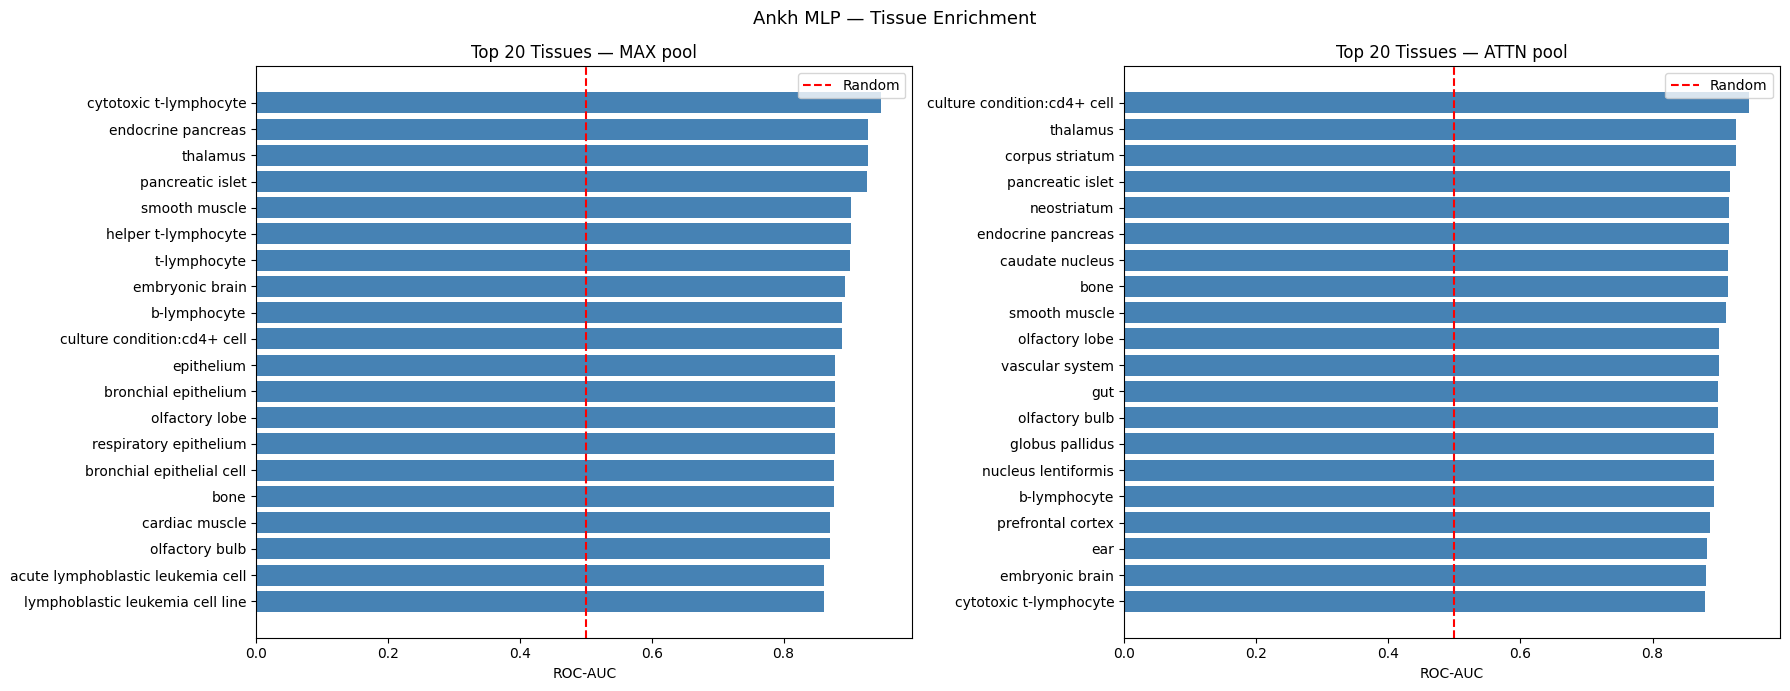

In [20]:

# ============================================================
# TOP / BOTTOM TISSUES BY ROC-AUC (both pools)
# ============================================================

metrics_by_pool = {}

for pool_name, res in eval_results.items():
    mdf = pd.DataFrame({
        "tissue":         res["tissue_names"],
        "roc_auc":        res["roc_aucs"],
        "pr_auc":         res["pr_aucs"],
        "pos_count_test": [
            int((res["Y_true"][:, TISSUE_COLS.index(t)] == 1).sum())
            for t in res["tissue_names"]
        ],
    }).sort_values("roc_auc", ascending=False)

    metrics_by_pool[pool_name] = mdf

    print(f"\n{'='*50}")
    print(f"  {pool_name.upper()} pool — Top 10 tissues by ROC-AUC")
    print(f"{'='*50}")
    display(mdf.head(10))

# Bar chart — top 20, both pools
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (pool_name, mdf) in zip(axes, metrics_by_pool.items()):
    top20 = mdf.head(20)
    ax.barh(top20["tissue"][::-1], top20["roc_auc"][::-1], color="steelblue")
    ax.axvline(0.5, color="red", linestyle="--", label="Random")
    ax.set_xlabel("ROC-AUC")
    ax.set_title(f"Top 20 Tissues — {pool_name.upper()} pool")
    ax.legend()

plt.suptitle("Ankh MLP — Tissue Enrichment", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top20_tissues_roc_auc.png"), dpi=150)
plt.show()


In [21]:

# ============================================================
# SAVE ALL RESULTS TO ankh_results/
# ============================================================

import torch

for pool_name, res in eval_results.items():
    mdf = metrics_by_pool[pool_name]

    # Per-tissue metrics
    mdf.to_csv(os.path.join(OUT_DIR, f"ankh_{pool_name}_per_tissue_metrics.csv"), index=False)

    # Test predictions
    pred_df = pd.DataFrame(res["Y_prob"], columns=TISSUE_COLS)
    pred_df.insert(0, "UniProt_ID", df_ml.iloc[idx_test]["UniProt_ID"].values)
    pred_df.insert(1, "GeneSym",    df_ml.iloc[idx_test]["GeneSym"].values)
    pred_df.to_csv(os.path.join(OUT_DIR, f"ankh_{pool_name}_test_predictions.csv"), index=False)

    # True labels (save once, same for both pools)
    if pool_name == "max":
        true_df = pd.DataFrame(res["Y_true"], columns=TISSUE_COLS)
        true_df.insert(0, "UniProt_ID", df_ml.iloc[idx_test]["UniProt_ID"].values)
        true_df.insert(1, "GeneSym",    df_ml.iloc[idx_test]["GeneSym"].values)
        true_df.to_csv(os.path.join(OUT_DIR, "ankh_test_true_labels.csv"), index=False)

    # Model weights
    model_obj, _ = trained_models[pool_name]
    torch.save(model_obj.state_dict(), os.path.join(OUT_DIR, f"ankh_{pool_name}_mlp_weights.pt"))

    print(f"[{pool_name}] Saved metrics, predictions, and model weights.")

# Summary table
summary_rows = []
for pool_name, res in eval_results.items():
    summary_rows.append({
        "pool":                pool_name,
        "model":               "Ankh Base + MLP",
        "embedding_dim":       emb_dim,
        "n_proteins_ml":       len(df_ml),
        "n_tissues":           len(TISSUE_COLS),
        "n_tissues_evaluated": len(res["roc_aucs"]),
        "train_size":          len(idx_train),
        "test_size":           len(idx_test),
        "macro_roc_auc":       float(res["roc_aucs"].mean()),
        "macro_pr_auc":        float(res["pr_aucs"].mean()),
        "epochs":              EPOCHS,
        "batch_size":          BATCH_SIZE,
        "lr":                  LR,
    })

summary_df = pd.DataFrame(summary_rows).set_index("pool")
summary_df.to_csv(os.path.join(OUT_DIR, "ankh_run_summary.csv"))

print("\n=== Run Summary ===")
display(summary_df.T)


[max] Saved metrics, predictions, and model weights.
[attn] Saved metrics, predictions, and model weights.

=== Run Summary ===


pool,max,attn
model,Ankh Base + MLP,Ankh Base + MLP
embedding_dim,768,768
n_proteins_ml,13081,13081
n_tissues,235,235
n_tissues_evaluated,235,235
train_size,10464,10464
test_size,2617,2617
macro_roc_auc,0.755793,0.792049
macro_pr_auc,0.220167,0.265038
epochs,40,40


Multiclass

In [22]:

# ============================================================
# MULTI-LABEL CLASSIFICATION — 5 TARGET TISSUES
# proteins can be enriched in multiple tissues simultaneously
# ============================================================

# Target tissue columns (exact names from gene_attribute_matrix)
TARGET_LABELS = [
    "brain",
    "testis",
    "lung",
    "liver",
    "kidney",
]

# Verify all targets exist in TISSUE_COLS
found, missing = [], []
for t in TARGET_LABELS:
    if t in TISSUE_COLS:
        found.append(t)
    else:
        match = next((c for c in TISSUE_COLS if c.lower() == t.lower()), None)
        if match:
            found.append(match)
        else:
            missing.append(t)

print("Found  :", found)
print("Missing:", missing)
TARGET_LABELS = found   # use verified names

SHORT_NAMES = [t.capitalize() for t in TARGET_LABELS]

# ─── Label matrix for the 5 targets ──────────────────────────────────────────
Y5 = df_ml[TARGET_LABELS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

# Class distribution
print("\nLabel distribution (# enriched / total):")
for i, (col, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    n_pos = int(Y5[:, i].sum())
    print(f"  {short:20s}: {n_pos:5d} / {len(Y5)}  ({100*n_pos/len(Y5):.1f}%)")

# Co-enrichment check
co = (Y5.sum(axis=1) > 1).sum()
print(f"\nProteins enriched in ≥2 labels: {co} ({100*co/len(Y5):.1f}%)")



Found  : ['brain', 'testis', 'lung', 'liver', 'kidney']
Missing: []

Label distribution (# enriched / total):
  Brain               :  7193 / 13081  (55.0%)
  Testis              :  3697 / 13081  (28.3%)
  Lung                :  2398 / 13081  (18.3%)
  Liver               :  1601 / 13081  (12.2%)
  Kidney              :  1600 / 13081  (12.2%)

Proteins enriched in ≥2 labels: 4160 (31.8%)


In [23]:

# ============================================================
# 3-WAY SPLIT: 70% train | 10% val | 20% test (unseen)
# use attn pool (best overall performance)
# ============================================================

from sklearn.model_selection import train_test_split

X5 = X_attn   # attn pool — better performer

idx5 = np.arange(len(X5))

# First carve out 20% test
idx5_trval, idx5_test = train_test_split(idx5, test_size=0.20, random_state=42)
# Then 10% of remaining as val (~11.1% of trval → 10% of total)
idx5_train, idx5_val  = train_test_split(idx5_trval, test_size=0.125, random_state=42)

X5_train = X5[idx5_train];  Y5_train = Y5[idx5_train]
X5_val   = X5[idx5_val];    Y5_val   = Y5[idx5_val]
X5_test  = X5[idx5_test];   Y5_test  = Y5[idx5_test]

print(f"Train : {len(idx5_train)} ({100*len(idx5_train)/len(X5):.1f}%)")
print(f"Val   : {len(idx5_val)}   ({100*len(idx5_val)/len(X5):.1f}%)")
print(f"Test  : {len(idx5_test)}  ({100*len(idx5_test)/len(X5):.1f}%)")

# Per-label positive weights from training set only
pos5      = Y5_train.sum(axis=0)
neg5      = len(Y5_train) - pos5
pw5       = np.where(pos5 > 0, neg5 / pos5, 1.0).astype(np.float32)
pw5_tensor = torch.from_numpy(pw5).to(device)
print(f"\nPos weights: {dict(zip(SHORT_NAMES, pw5.round(1)))}")


Train : 9156 (70.0%)
Val   : 1308   (10.0%)
Test  : 2617  (20.0%)

Pos weights: {'Brain': np.float32(0.8), 'Testis': np.float32(2.6), 'Lung': np.float32(4.5), 'Liver': np.float32(7.2), 'Kidney': np.float32(7.1)}


Epoch 025/300 | Train: 1.0257 | Val: 1.0486
Epoch 050/300 | Train: 1.0087 | Val: 1.0399
Epoch 075/300 | Train: 0.9973 | Val: 1.0387
Epoch 100/300 | Train: 0.9901 | Val: 1.0373
Epoch 125/300 | Train: 0.9856 | Val: 1.0377
Epoch 150/300 | Train: 0.9797 | Val: 1.0380
Early stopping @ epoch 156  (best val=1.0363 @ ep 126)

Restored best model from epoch 126  (val=1.0363)


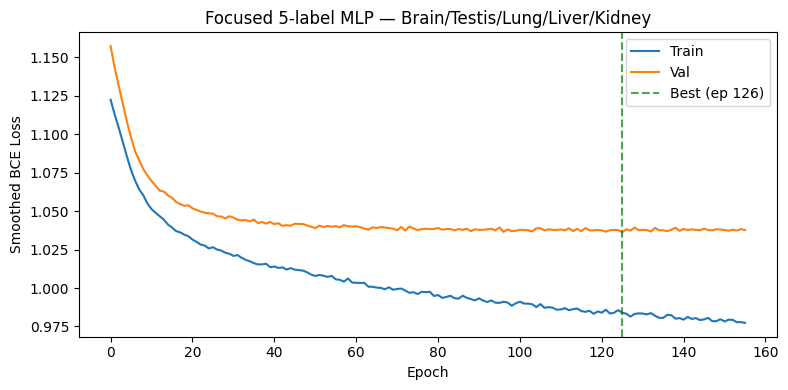

In [24]:

# ============================================================
# RETRAIN — 1-hidden-layer MLP, label smoothing, AdamW
# Fixes overfitting: simpler arch + stronger regularization
# ============================================================

import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class FocusedMLP(nn.Module):
    def __init__(self, input_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, num_labels),
        )
    def forward(self, x): return self.net(x)

EPOCHS5 = 300; BATCH_SIZE5 = 256; LR5 = 3e-4; PATIENCE5 = 30
LABEL_SMOOTH = 0.05   # prevents overconfidence on noisy labels

train5_ds = TensorDataset(torch.from_numpy(X5_train), torch.from_numpy(Y5_train))
val5_ds   = TensorDataset(torch.from_numpy(X5_val),   torch.from_numpy(Y5_val))
train5_loader = DataLoader(train5_ds, batch_size=BATCH_SIZE5, shuffle=True)
val5_loader   = DataLoader(val5_ds,   batch_size=BATCH_SIZE5, shuffle=False)

pw5_capped = torch.clamp(pw5_tensor, max=20.0)

def smooth_bce(logits, targets, pw, s=0.05):
    t = targets * (1 - s) + (1 - targets) * s
    return nn.BCEWithLogitsLoss(pos_weight=pw)(logits, t)

model5     = FocusedMLP(X5_train.shape[1], 5).to(device)
optimizer5 = torch.optim.AdamW(model5.parameters(), lr=LR5, weight_decay=5e-2)
scheduler5 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer5, T_max=EPOCHS5, eta_min=1e-6
)

train_losses5, val_losses5 = [], []
best_val5, best_epoch5, best_state5, patience_cnt = float("inf"), 0, None, 0

for epoch in range(1, EPOCHS5 + 1):
    model5.train(); tr_loss = 0.0
    for xb, yb in train5_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer5.zero_grad()
        loss = smooth_bce(model5(xb), yb, pw5_capped, LABEL_SMOOTH)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model5.parameters(), 1.0)
        optimizer5.step(); tr_loss += loss.item()

    model5.eval(); v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val5_loader:
            v_loss += smooth_bce(model5(xb.to(device)), yb.to(device), pw5_capped, LABEL_SMOOTH).item()

    t_avg = tr_loss / len(train5_loader)
    v_avg = v_loss  / len(val5_loader)
    train_losses5.append(t_avg); val_losses5.append(v_avg)
    scheduler5.step()

    if v_avg < best_val5:
        best_val5, best_epoch5 = v_avg, epoch
        best_state5 = {k: v.cpu().clone() for k, v in model5.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE5:
            print(f"Early stopping @ epoch {epoch}  (best val={best_val5:.4f} @ ep {best_epoch5})")
            break

    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d}/{EPOCHS5} | Train: {t_avg:.4f} | Val: {v_avg:.4f}")

model5.load_state_dict({k: v.to(device) for k, v in best_state5.items()})
print(f"\nRestored best model from epoch {best_epoch5}  (val={best_val5:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses5, label="Train", lw=1.5)
ax.plot(val_losses5,   label="Val",   lw=1.5)
ax.axvline(best_epoch5 - 1, ls="--", color="green", alpha=0.7, label=f"Best (ep {best_epoch5})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Smoothed BCE Loss")
ax.set_title("Focused 5-label MLP — Brain/Testis/Lung/Liver/Kidney")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_training_loss.png"), dpi=150)
plt.show()


Epoch 010/100 | Train: 0.6675 | Val: 1.0513
Early stopping at epoch 17 (best val=0.9271 @ epoch 2)

Restored best model from epoch 2 (val loss=0.9271)


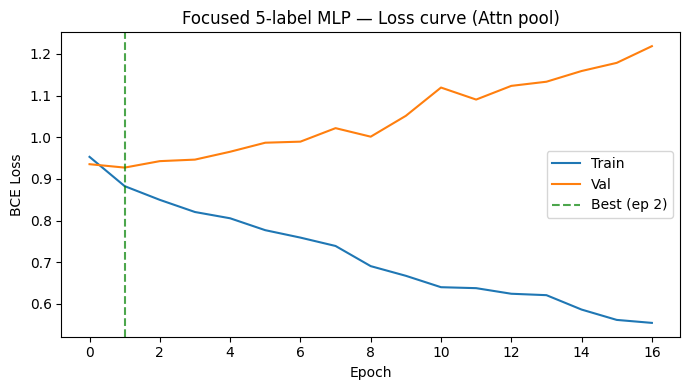

In [25]:

# ============================================================
# DEFINE & TRAIN FOCUSED 5-LABEL MLP
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class FocusedMLP(nn.Module):
    """Deeper MLP for the 5-label focused classification."""
    def __init__(self, input_dim: int, num_labels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_labels),
        )

    def forward(self, x):
        return self.net(x)


EPOCHS5     = 100
BATCH_SIZE5 = 64
LR5         = 5e-4
PATIENCE5   = 15          # early stopping patience

train5_ds = TensorDataset(torch.from_numpy(X5_train), torch.from_numpy(Y5_train))
val5_ds   = TensorDataset(torch.from_numpy(X5_val),   torch.from_numpy(Y5_val))

train5_loader = DataLoader(train5_ds, batch_size=BATCH_SIZE5, shuffle=True)
val5_loader   = DataLoader(val5_ds,   batch_size=BATCH_SIZE5, shuffle=False)

# Cap pos_weight to reduce overfitting on very rare positives
pw5_capped = torch.clamp(pw5_tensor, max=50.0)

model5     = FocusedMLP(input_dim=X5_train.shape[1], num_labels=5).to(device)
criterion5 = nn.BCEWithLogitsLoss(pos_weight=pw5_capped)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=LR5, weight_decay=1e-3)
scheduler5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer5, patience=5,
                                                         factor=0.5)

train_losses5, val_losses5 = [], []
best_val5   = float("inf")
best_epoch5 = 0
best_state5 = None
patience_cnt = 0

for epoch in range(1, EPOCHS5 + 1):
    # ── train ──────────────────────────────────────────────
    model5.train()
    tr_loss = 0.0
    for xb, yb in train5_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer5.zero_grad()
        loss = criterion5(model5(xb), yb)
        loss.backward()
        optimizer5.step()
        tr_loss += loss.item()

    # ── val ────────────────────────────────────────────────
    model5.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val5_loader:
            v_loss += criterion5(model5(xb.to(device)), yb.to(device)).item()

    t_avg = tr_loss / len(train5_loader)
    v_avg = v_loss  / len(val5_loader)
    train_losses5.append(t_avg)
    val_losses5.append(v_avg)
    scheduler5.step(v_avg)

    if v_avg < best_val5:
        best_val5   = v_avg
        best_epoch5 = epoch
        best_state5 = {k: v.cpu().clone() for k, v in model5.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE5:
            print(f"Early stopping at epoch {epoch} (best val={best_val5:.4f} @ epoch {best_epoch5})")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}/{EPOCHS5} | Train: {t_avg:.4f} | Val: {v_avg:.4f}")

# Restore best model
model5.load_state_dict({k: v.to(device) for k, v in best_state5.items()})
print(f"\nRestored best model from epoch {best_epoch5} (val loss={best_val5:.4f})")

# Loss curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses5, label="Train")
ax.plot(val_losses5,   label="Val")
ax.axvline(best_epoch5 - 1, ls="--", color="green", alpha=0.7, label=f"Best (ep {best_epoch5})")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Focused 5-label MLP — Loss curve (Attn pool)")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_training_loss.png"), dpi=150)
plt.show()


In [26]:

# ============================================================
# VALIDATION PERFORMANCE — threshold tuning per label
# ============================================================

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

def predict_proba5(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)


val_prob5, val_true5 = predict_proba5(model5, val5_loader)

# Find best threshold per label (maximise F1 on val)
thresholds_grid = np.arange(0.1, 0.9, 0.05)
best_thresh = []
for i in range(5):
    best_f1, best_t = -1, 0.5
    for t in thresholds_grid:
        pred = (val_prob5[:, i] >= t).astype(int)
        if pred.sum() == 0:
            continue
        f1 = f1_score(val_true5[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh.append(best_t)

print("Optimal thresholds per label (tuned on val):")
for name, t in zip(SHORT_NAMES, best_thresh):
    print(f"  {name:20s}: {t:.2f}")

# Val stats summary
print("\n=== Validation set metrics ===")
val_pred5 = (val_prob5 >= np.array(best_thresh)).astype(int)

rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    roc = roc_auc_score(val_true5[:, i], val_prob5[:, i])
    ap  = average_precision_score(val_true5[:, i], val_prob5[:, i])
    p   = precision_score(val_true5[:, i], val_pred5[:, i], zero_division=0)
    r   = recall_score(val_true5[:, i], val_pred5[:, i], zero_division=0)
    f1  = f1_score(val_true5[:, i], val_pred5[:, i], zero_division=0)
    rows.append(dict(label=short, roc_auc=roc, pr_auc=ap,
                     precision=p, recall=r, f1=f1,
                     threshold=best_thresh[i]))

val_stats = pd.DataFrame(rows).set_index("label")
display(val_stats.round(4))


Optimal thresholds per label (tuned on val):
  Brain               : 0.35
  Testis              : 0.45
  Lung                : 0.50
  Liver               : 0.60
  Kidney              : 0.65

=== Validation set metrics ===


,roc_auc,pr_auc,precision,recall,f1,threshold
label,,,,,,
Brain,0.7002,0.7412,0.6201,0.8832,0.7286,0.35
Testis,0.7112,0.5153,0.4426,0.6821,0.5368,0.45
Lung,0.7169,0.3880,0.3655,0.5830,0.4493,0.50
Liver,0.7768,0.3346,0.3200,0.4865,0.3861,0.60
Kidney,0.7425,0.3349,0.3631,0.3846,0.3736,0.65


=== Test set (unseen) — per-label metrics ===


,roc_auc,pr_auc,precision,recall,f1
label,,,,,
Brain,0.6980,0.7387,0.6147,0.8869,0.7262
Testis,0.6855,0.4782,0.4096,0.6641,0.5067
Lung,0.7072,0.4055,0.3409,0.5749,0.4280
Liver,0.8007,0.4082,0.3780,0.5801,0.4577
Kidney,0.7749,0.3860,0.3781,0.4967,0.4294


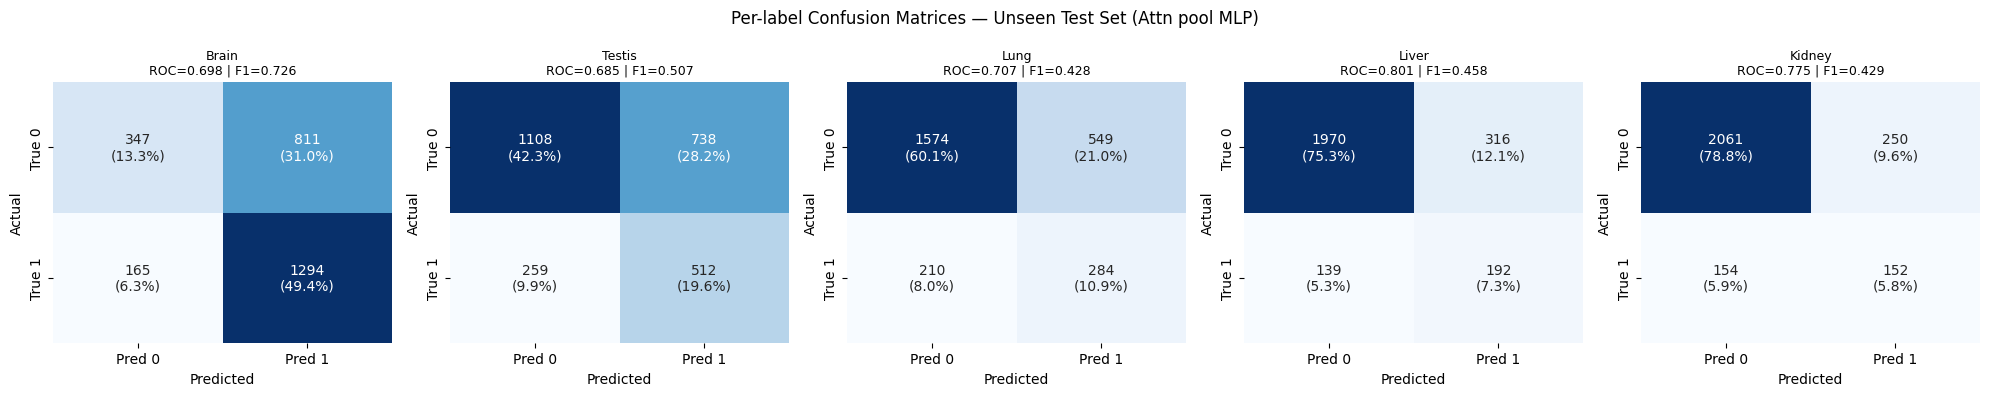

In [27]:

# ============================================================
# TEST ON UNSEEN SET — metrics + per-label confusion matrices
# ============================================================

test5_ds     = TensorDataset(torch.from_numpy(X5_test), torch.from_numpy(Y5_test))
test5_loader = DataLoader(test5_ds, batch_size=BATCH_SIZE5, shuffle=False)

test_prob5, test_true5 = predict_proba5(model5, test5_loader)
test_pred5 = (test_prob5 >= np.array(best_thresh)).astype(int)

# ─── Per-label test metrics table ──────────────────────────
test_rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    roc = roc_auc_score(test_true5[:, i], test_prob5[:, i])
    ap  = average_precision_score(test_true5[:, i], test_prob5[:, i])
    p   = precision_score(test_true5[:, i], test_pred5[:, i], zero_division=0)
    r   = recall_score(test_true5[:, i], test_pred5[:, i], zero_division=0)
    f1  = f1_score(test_true5[:, i], test_pred5[:, i], zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_true5[:, i], test_pred5[:, i]).ravel()
    test_rows.append(dict(label=short, roc_auc=roc, pr_auc=ap,
                          precision=p, recall=r, f1=f1,
                          TP=tp, FP=fp, FN=fn, TN=tn,
                          threshold=best_thresh[i]))

test_stats = pd.DataFrame(test_rows).set_index("label")

print("=== Test set (unseen) — per-label metrics ===")
display(test_stats[["roc_auc", "pr_auc", "precision", "recall", "f1"]].round(4))

# ─── Multi-label confusion matrices (one per label) ────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, short) in enumerate(zip(axes, SHORT_NAMES)):
    cm = confusion_matrix(test_true5[:, i], test_pred5[:, i])
    # Annotate with counts + percentages
    total = cm.sum()
    annot = np.array([[f"{v}\n({100*v/total:.1f}%)" for v in row] for row in cm])

    sns.heatmap(
        cm, annot=annot, fmt="", ax=ax,
        cmap="Blues", cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
    )
    ax.set_title(f"{short}\nROC={test_stats.loc[short,'roc_auc']:.3f} | F1={test_stats.loc[short,'f1']:.3f}",
                 fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Per-label Confusion Matrices — Unseen Test Set (Attn pool MLP)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_confusion_matrices.png"), dpi=150)
plt.show()


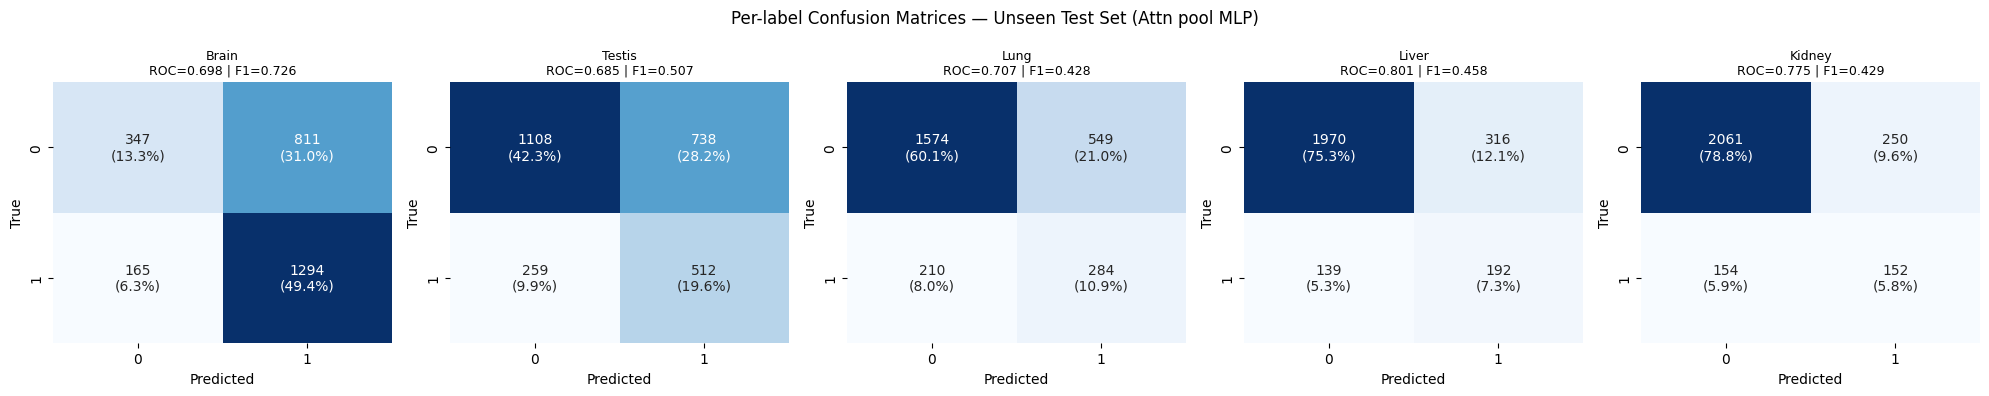

In [28]:

# ============================================================
# CONFUSION MATRICES — re-plot with clean True / Predicted axes
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, short) in enumerate(zip(axes, SHORT_NAMES)):
    cm    = confusion_matrix(test_true5[:, i], test_pred5[:, i])
    total = cm.sum()
    annot = np.array([[f"{v}\n({100*v/total:.1f}%)" for v in row] for row in cm])

    sns.heatmap(
        cm, annot=annot, fmt="", ax=ax,
        cmap="Blues", cbar=False,
        xticklabels=["0", "1"],
        yticklabels=["0", "1"],
    )
    ax.set_title(
        f"{short}\nROC={test_stats.loc[short,'roc_auc']:.3f} | F1={test_stats.loc[short,'f1']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Per-label Confusion Matrices — Unseen Test Set (Attn pool MLP)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_confusion_matrices.png"), dpi=150)
plt.show()


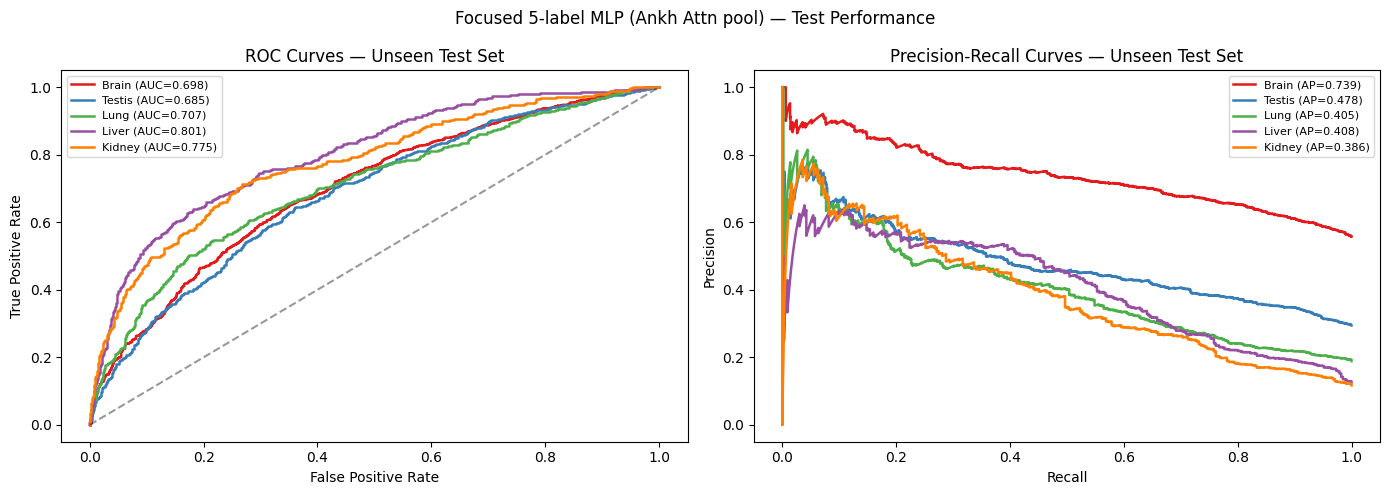


=== Multi-label co-enrichment in predictions (test set) ===


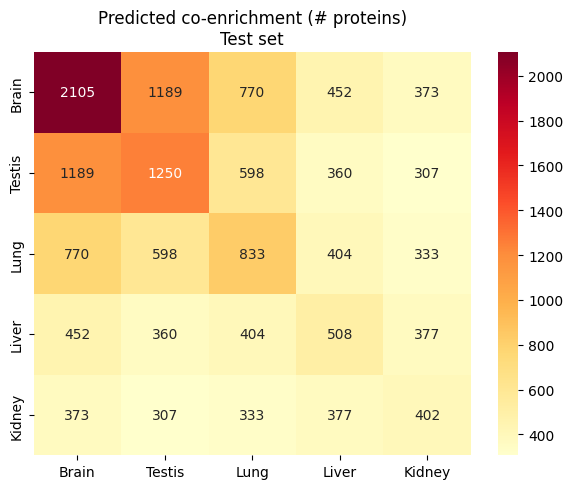

In [29]:

# ============================================================
# ROC & PR CURVES — test set, all 5 labels
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

for i, (short, color) in enumerate(zip(SHORT_NAMES, colors)):
    fpr, tpr, _ = roc_curve(test_true5[:, i], test_prob5[:, i])
    prec, rec, _ = precision_recall_curve(test_true5[:, i], test_prob5[:, i])

    roc_val = test_stats.loc[short, "roc_auc"]
    ap_val  = test_stats.loc[short, "pr_auc"]

    axes[0].plot(fpr, tpr, color=color, lw=1.8,
                 label=f"{short} (AUC={roc_val:.3f})")
    axes[1].plot(rec, prec, color=color, lw=1.8,
                 label=f"{short} (AP={ap_val:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Unseen Test Set"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Unseen Test Set")
axes[1].legend(fontsize=8)

plt.suptitle("Focused 5-label MLP (Ankh Attn pool) — Test Performance", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_roc_pr_curves.png"), dpi=150)
plt.show()

# ─── Co-enrichment heatmap (predicted label co-occurrence) ─
from sklearn.metrics import multilabel_confusion_matrix

print("\n=== Multi-label co-enrichment in predictions (test set) ===")
pred_comat = (test_pred5.T @ test_pred5)
pred_codf  = pd.DataFrame(pred_comat, index=SHORT_NAMES, columns=SHORT_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pred_codf, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar=True)
ax.set_title("Predicted co-enrichment (# proteins)\nTest set")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_co_enrichment.png"), dpi=150)
plt.show()


In [30]:

# ============================================================
# SAVE FOCUSED MODEL RESULTS
# ============================================================

# Full test metrics (with TP/FP/FN/TN)
test_stats.to_csv(os.path.join(OUT_DIR, "focused5_test_metrics.csv"))
print(f"Saved test metrics → {os.path.join(OUT_DIR, 'focused5_test_metrics.csv')}")

# Predictions on test set
pred_out = pd.DataFrame(test_prob5,  columns=[f"prob_{s}"  for s in SHORT_NAMES])
for i, s in enumerate(SHORT_NAMES):
    pred_out[f"pred_{s}"] = test_pred5[:, i]
    pred_out[f"true_{s}"] = test_true5[:, i].astype(int)
pred_out.insert(0, "UniProt_ID", df_ml.iloc[idx5_test]["UniProt_ID"].values)
pred_out.insert(1, "GeneSym",    df_ml.iloc[idx5_test]["GeneSym"].values)
pred_out.to_csv(os.path.join(OUT_DIR, "focused5_test_predictions.csv"), index=False)
print(f"Saved test predictions → {os.path.join(OUT_DIR, 'focused5_test_predictions.csv')}")

# Model weights
torch.save(model5.state_dict(), os.path.join(OUT_DIR, "focused5_mlp_weights.pt"))
print(f"Saved model weights → {os.path.join(OUT_DIR, 'focused5_mlp_weights.pt')}")

# Summary
from sklearn.metrics import hamming_loss
print(f"\nHamming loss (test) : {hamming_loss(test_true5, test_pred5):.4f}")
print(f"Macro F1    (test) : {f1_score(test_true5, test_pred5, average='macro',  zero_division=0):.4f}")
print(f"Micro F1    (test) : {f1_score(test_true5, test_pred5, average='micro',  zero_division=0):.4f}")
print(f"Sample F1   (test) : {f1_score(test_true5, test_pred5, average='samples',zero_division=0):.4f}")
print(f"\nMacro ROC-AUC      : {test_stats['roc_auc'].mean():.4f}")
print(f"Macro PR-AUC       : {test_stats['pr_auc'].mean():.4f}")


Saved test metrics → ankh_results/focused5_test_metrics.csv
Saved test predictions → ankh_results/focused5_test_predictions.csv
Saved model weights → ankh_results/focused5_mlp_weights.pt

Hamming loss (test) : 0.2744
Macro F1    (test) : 0.5096
Micro F1    (test) : 0.5755
Sample F1   (test) : 0.4044

Macro ROC-AUC      : 0.7333
Macro PR-AUC       : 0.4833


In [31]:

# ============================================================
# METRICS VS RANDOM BASELINE — comparison table
# Baselines:
#   ROC-AUC  = 0.5            (random ranking)
#   PR-AUC   = prevalence     (no-skill classifier)
#   F1       = 2·p / (1 + p)  (random classifier predicting pos at rate p)
# ============================================================

baseline_rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    prev     = float(test_true5[:, i].mean())
    rand_roc = 0.5
    rand_pr  = prev
    rand_f1  = 2 * prev / (1 + prev) if prev > 0 else 0.0

    baseline_rows.append(dict(
        label        = short,
        prevalence   = round(prev, 4),
        ROC_model    = round(test_stats.loc[short, "roc_auc"], 4),
        ROC_random   = rand_roc,
        ROC_gain     = round(test_stats.loc[short, "roc_auc"] - rand_roc, 4),
        PRAUC_model  = round(test_stats.loc[short, "pr_auc"],  4),
        PRAUC_random = round(rand_pr, 4),
        PRAUC_gain   = round(test_stats.loc[short, "pr_auc"] - rand_pr, 4),
        F1_model     = round(test_stats.loc[short, "f1"], 4),
        F1_random    = round(rand_f1, 4),
        F1_gain      = round(test_stats.loc[short, "f1"] - rand_f1, 4),
    ))

comp_df = pd.DataFrame(baseline_rows).set_index("label")
print("=== Test Metrics vs Random Baseline ===")
display(comp_df)
comp_df.to_csv(os.path.join(OUT_DIR, "focused5_baseline_comparison.csv"))
print(f"\nSaved → {os.path.join(OUT_DIR, 'focused5_baseline_comparison.csv')}")


=== Test Metrics vs Random Baseline ===


,prevalence,ROC_model,ROC_random,ROC_gain,PRAUC_model,PRAUC_random,PRAUC_gain,F1_model,F1_random,F1_gain
label,,,,,,,,,,
Brain,0.5575,0.6980,0.5,0.1980,0.7387,0.5575,0.1812,0.7262,0.7159,0.0103
Testis,0.2946,0.6855,0.5,0.1855,0.4782,0.2946,0.1836,0.5067,0.4551,0.0515
Lung,0.1888,0.7072,0.5,0.2072,0.4055,0.1888,0.2167,0.4280,0.3176,0.1105
Liver,0.1265,0.8007,0.5,0.3007,0.4082,0.1265,0.2817,0.4577,0.2246,0.2331
Kidney,0.1169,0.7749,0.5,0.2749,0.3860,0.1169,0.2691,0.4294,0.2094,0.2200



Saved → ankh_results/focused5_baseline_comparison.csv


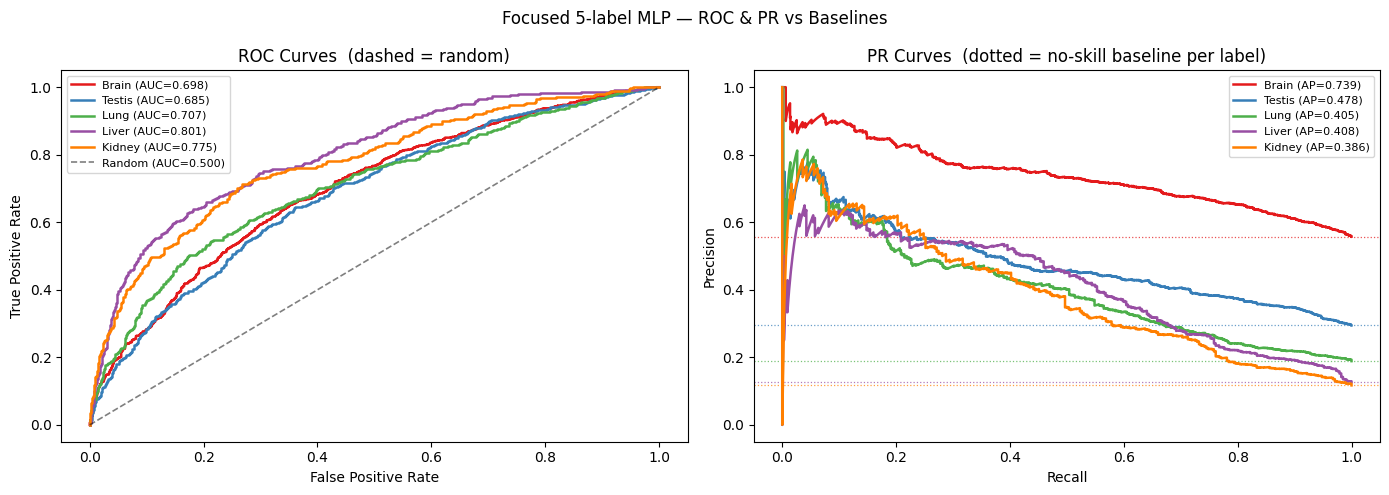

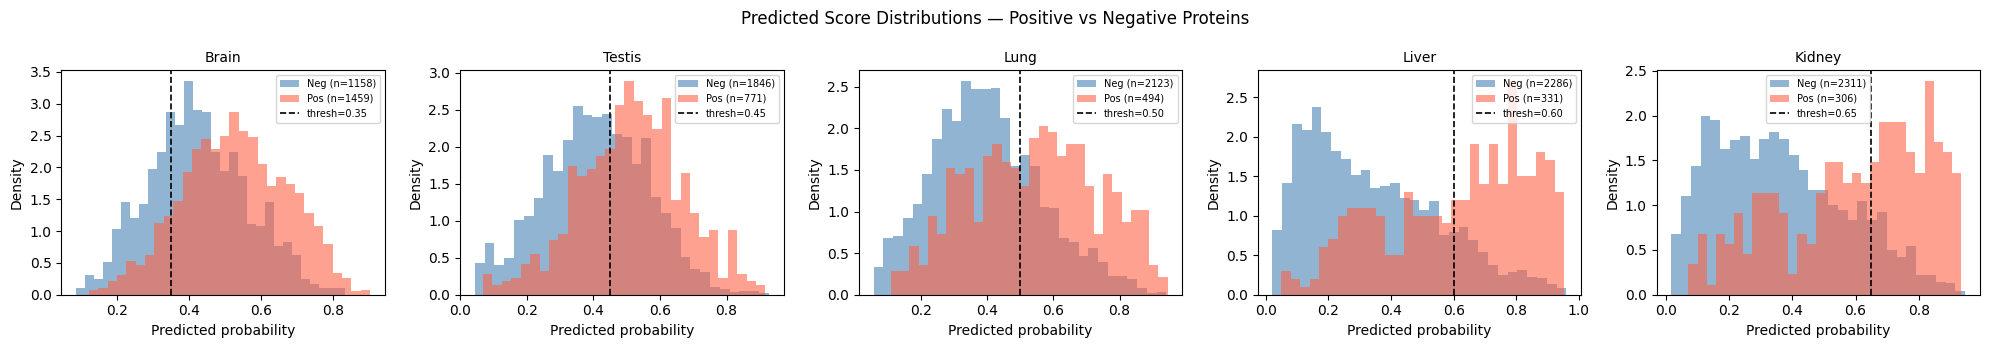

In [32]:

# ============================================================
# (A) ROC / PR CURVES WITH BASELINES
# (B) SCORE DISTRIBUTIONS — positive vs negative proteins
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

# ─── (A) ROC + PR with explicit baselines ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (short, color) in enumerate(zip(SHORT_NAMES, colors)):
    fpr, tpr, _  = roc_curve(test_true5[:, i], test_prob5[:, i])
    prec, rec, _ = precision_recall_curve(test_true5[:, i], test_prob5[:, i])
    prev = test_true5[:, i].mean()

    axes[0].plot(fpr, tpr, color=color, lw=1.8,
                 label=f"{short} (AUC={test_stats.loc[short,'roc_auc']:.3f})")
    axes[1].plot(rec, prec, color=color, lw=1.8,
                 label=f"{short} (AP={test_stats.loc[short,'pr_auc']:.3f})")
    # No-skill PR baseline = prevalence (dotted, same colour)
    axes[1].axhline(prev, color=color, lw=0.9, ls=":", alpha=0.75)

axes[0].plot([0,1],[0,1], "k--", alpha=0.5, lw=1.2, label="Random (AUC=0.500)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves  (dashed = random)"); axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves  (dotted = no-skill baseline per label)")
axes[1].legend(fontsize=8)

plt.suptitle("Focused 5-label MLP — ROC & PR vs Baselines", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_roc_pr_with_baseline.png"), dpi=150)
plt.show()

# ─── (B) Score distributions: pos vs neg ────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

for i, (ax, short, color) in enumerate(zip(axes, SHORT_NAMES, colors)):
    pos_mask = test_true5[:, i].astype(bool)
    neg_mask = ~pos_mask

    ax.hist(test_prob5[neg_mask, i], bins=30, alpha=0.6, color="steelblue",
            label=f"Neg (n={neg_mask.sum()})", density=True)
    ax.hist(test_prob5[pos_mask, i], bins=30, alpha=0.6, color="tomato",
            label=f"Pos (n={pos_mask.sum()})", density=True)
    ax.axvline(best_thresh[i], color="black", ls="--", lw=1.2,
               label=f"thresh={best_thresh[i]:.2f}")
    ax.set_title(f"{short}", fontsize=10)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("Predicted Score Distributions — Positive vs Negative Proteins", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_score_distributions.png"), dpi=150)
plt.show()


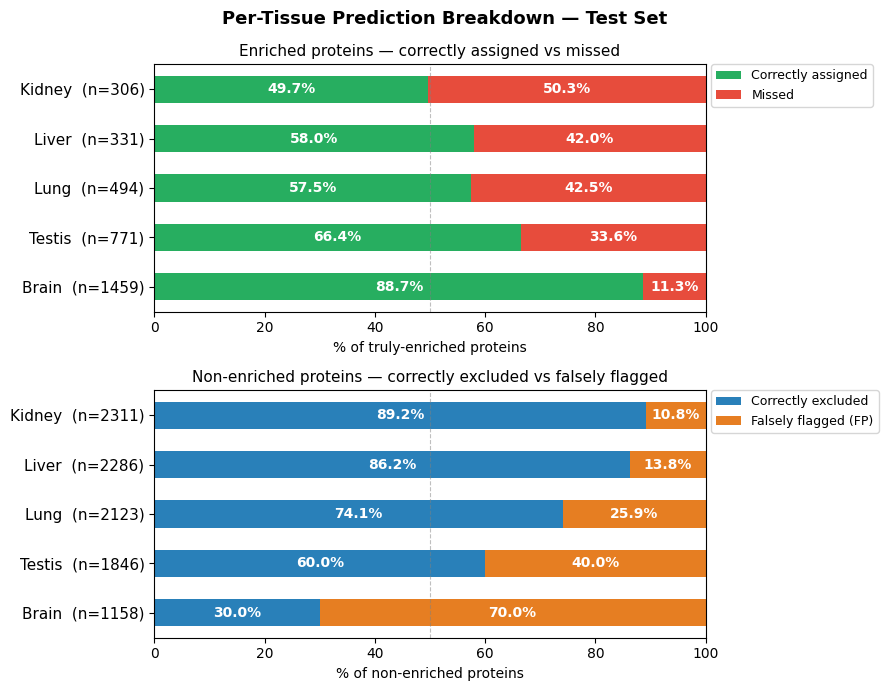

In [36]:

# ============================================================
# PER-TISSUE RECALL BREAKDOWN
# Of the truly-enriched proteins, what % were correctly called
# vs missed — and of non-enriched, what % were falsely flagged
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=False)

colors_pos = ["#27ae60", "#e74c3c"]   # correct / missed (positives)
colors_neg = ["#2980b9", "#e67e22"]   # correct / falsely flagged (negatives)

recalls, miss_rates, specs, fpr_rates, n_pos_list, n_neg_list = [], [], [], [], [], []
for i, short in enumerate(SHORT_NAMES):
    tp = test_stats.loc[short, "TP"]
    fn = test_stats.loc[short, "FN"]
    tn = test_stats.loc[short, "TN"]
    fp = test_stats.loc[short, "FP"]
    n_pos = tp + fn
    n_neg = tn + fp
    recalls.append(tp / n_pos * 100)
    miss_rates.append(fn / n_pos * 100)
    specs.append(tn / n_neg * 100)
    fpr_rates.append(fp / n_neg * 100)
    n_pos_list.append(n_pos)
    n_neg_list.append(n_neg)

y = np.arange(len(SHORT_NAMES))
h = 0.55

# ── Enriched proteins (positives) ──────────────────────────
axes[0].barh(y, recalls,    height=h, color=colors_pos[0], label="Correctly assigned")
axes[0].barh(y, miss_rates, height=h, left=recalls,        color=colors_pos[1], label="Missed")
for i, (r, m) in enumerate(zip(recalls, miss_rates)):
    axes[0].text(r / 2,     i, f"{r:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    axes[0].text(r + m / 2, i, f"{m:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{s}  (n={n})" for s, n in zip(SHORT_NAMES, n_pos_list)], fontsize=11)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("% of truly-enriched proteins", fontsize=10)
axes[0].set_title("Enriched proteins — correctly assigned vs missed", fontsize=11)
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
axes[0].axvline(50, color="gray", ls="--", lw=0.8, alpha=0.5)

# ── Non-enriched proteins (negatives) ──────────────────────
axes[1].barh(y, specs,      height=h, color=colors_neg[0], label="Correctly excluded")
axes[1].barh(y, fpr_rates,  height=h, left=specs,          color=colors_neg[1], label="Falsely flagged (FP)")
for i, (s, f) in enumerate(zip(specs, fpr_rates)):
    axes[1].text(s / 2,     i, f"{s:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    axes[1].text(s + f / 2, i, f"{f:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
axes[1].set_yticks(y)
axes[1].set_yticklabels([f"{s}  (n={n})" for s, n in zip(SHORT_NAMES, n_neg_list)], fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("% of non-enriched proteins", fontsize=10)
axes[1].set_title("Non-enriched proteins — correctly excluded vs falsely flagged", fontsize=11)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
axes[1].axvline(50, color="gray", ls="--", lw=0.8, alpha=0.5)

plt.suptitle("Per-Tissue Prediction Breakdown — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_recall_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()


/home/saishyam/ankh_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running PCA...
  Variance explained: PC1=14.4%  PC2=6.8%
Running UMAP (may take ~1 min)...


/home/saishyam/ankh_env/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP done.


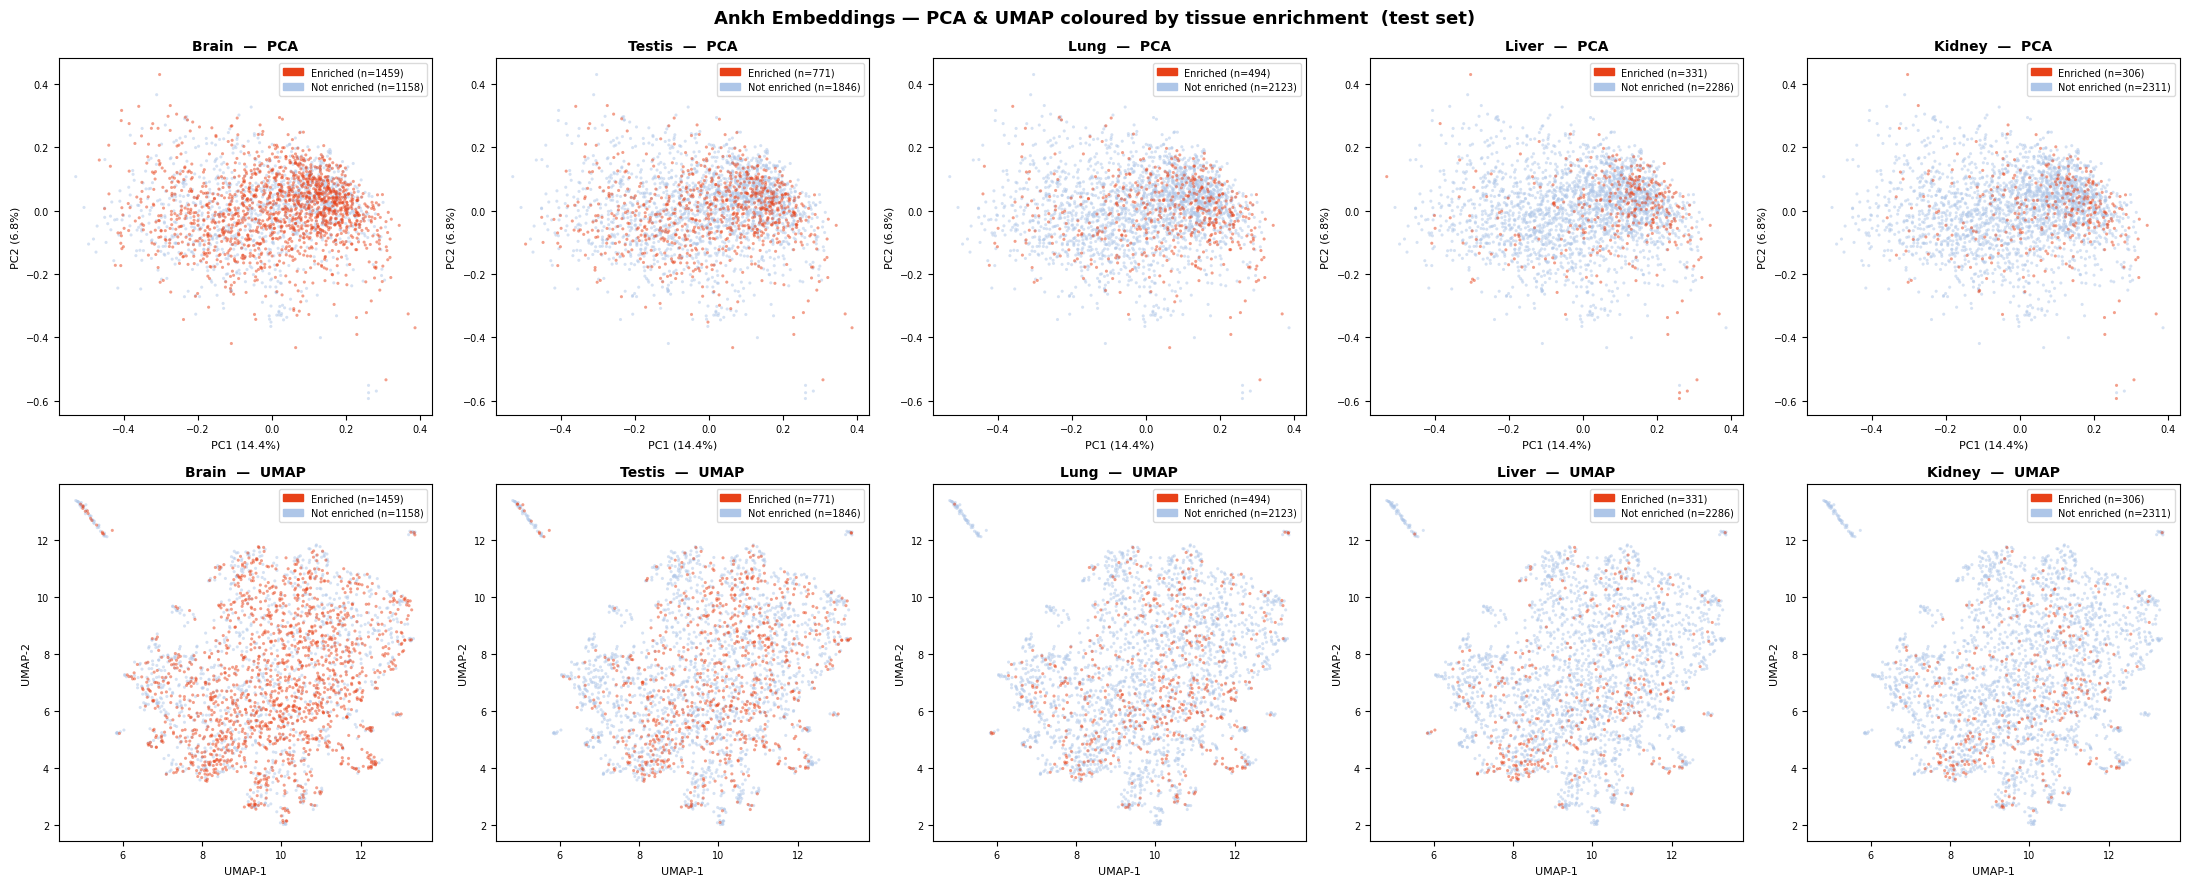

Saved → ankh_results/focused5_pca_umap.png


In [34]:

# ============================================================
# PCA & UMAP — test-set embeddings coloured by tissue enrichment
# ============================================================

from sklearn.decomposition import PCA
from matplotlib.patches import Patch

try:
    import umap as umap_module
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed — installing now...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn"], check=True)
    import umap as umap_module
    HAS_UMAP = True

# ─── Embeddings + ground-truth labels (test set) ─────────────
X_embed = X5_test          # shape: (n_test, 768)
Y_embed = test_true5       # shape: (n_test, 5)

# ─── PCA ──────────────────────────────────────────────────────
print("Running PCA...")
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_embed)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
print(f"  Variance explained: PC1={var_pc1:.1f}%  PC2={var_pc2:.1f}%")

# ─── UMAP ─────────────────────────────────────────────────────
print("Running UMAP (may take ~1 min)...")
reducer = umap_module.UMAP(n_components=2, n_neighbors=30, min_dist=0.3,
                            random_state=42, verbose=False)
X_umap  = reducer.fit_transform(X_embed)
print("  UMAP done.")

# ─── Palette ──────────────────────────────────────────────────
COL_POS = "#e84118"   # enriched    — red
COL_NEG = "#aec6e8"   # not enriched — light blue

# ─── Plot: 2 rows (PCA / UMAP) × 5 tissues ───────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col, short in enumerate(SHORT_NAMES):
    lbl    = Y_embed[:, col].astype(int)
    colors = np.where(lbl == 1, COL_POS, COL_NEG)
    order  = np.argsort(lbl)          # negatives first so positives sit on top
    n_pos  = int(lbl.sum())
    n_neg  = len(lbl) - n_pos

    legend_handles = [
        Patch(color=COL_POS, label=f"Enriched (n={n_pos})"),
        Patch(color=COL_NEG, label=f"Not enriched (n={n_neg})"),
    ]

    # ── PCA row ──────────────────────────────────────────────
    ax = axes[0, col]
    ax.scatter(X_pca[order, 0], X_pca[order, 1],
               c=colors[order], s=5, alpha=0.5, linewidths=0)
    ax.set_title(f"{short}  —  PCA", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var_pc1:.1f}%)", fontsize=8)
    ax.set_ylabel(f"PC2 ({var_pc2:.1f}%)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(handles=legend_handles, fontsize=7, loc="best", framealpha=0.7)

    # ── UMAP row ─────────────────────────────────────────────
    ax2 = axes[1, col]
    ax2.scatter(X_umap[order, 0], X_umap[order, 1],
                c=colors[order], s=5, alpha=0.5, linewidths=0)
    ax2.set_title(f"{short}  —  UMAP", fontsize=10, fontweight="bold")
    ax2.set_xlabel("UMAP-1", fontsize=8)
    ax2.set_ylabel("UMAP-2", fontsize=8)
    ax2.tick_params(labelsize=7)
    ax2.legend(handles=legend_handles, fontsize=7, loc="best", framealpha=0.7)

plt.suptitle(
    "Ankh Embeddings — PCA & UMAP coloured by tissue enrichment  (test set)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_pca_umap.png"), dpi=150)
plt.show()
print(f"Saved → {os.path.join(OUT_DIR, 'focused5_pca_umap.png')}")
